In [1]:
# Importações básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Bibliotecas especializadas
import math
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

print(" Bibliotecas importadas!")

 Bibliotecas importadas!


Carregamento e Exploração de Dados

In [2]:
from pathlib import Path
import pandas as pd

path = Path('../../data/Airbnb Prices in European Cities/raw')

# arquivos
weekends = pd.read_csv(path / "london_weekends.csv")
weekdays = pd.read_csv(path / "london_weekdays.csv")

# junta os dois DataFrames linha a linha
df = pd.concat([weekdays, weekends], ignore_index=True)

print("Arquivos carregados e unidos!")
print(df.shape)


Arquivos carregados e unidos!
(9993, 20)


In [3]:
cols_lfs = [
    'version https://git-lfs.github.com/spec/v1',
    'oid sha256',
    'size'
]

df = df.drop(columns=[c for c in cols_lfs if c in df.columns])


Análise Exploratória Estrutural

In [4]:
# 1. Informações básicas do dataset
print("\n1️⃣ INFORMAÇÕES GERAIS:")
print(f"Dimensões: {df.shape}")
print(f"Memória: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


1️⃣ INFORMAÇÕES GERAIS:
Dimensões: (9993, 20)
Memória: 1.92 MB


In [5]:
# 2. Tipos de dados
print("\n2️⃣ TIPOS DE DADOS:")
print(df.dtypes)


2️⃣ TIPOS DE DADOS:
Unnamed: 0                      int64
realSum                       float64
room_type                      object
room_shared                      bool
room_private                     bool
person_capacity               float64
host_is_superhost                bool
multi                           int64
biz                             int64
cleanliness_rating            float64
guest_satisfaction_overall    float64
bedrooms                        int64
dist                          float64
metro_dist                    float64
attr_index                    float64
attr_index_norm               float64
rest_index                    float64
rest_index_norm               float64
lng                           float64
lat                           float64
dtype: object


In [6]:
# 3. Primeiras linhas
print("\n3️⃣ PRIMEIRAS 5 LINHAS:")
display(df.head())


3️⃣ PRIMEIRAS 5 LINHAS:


,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
0,0,570.098074,Entire home/apt,False,False,2.0,False,0,0,10.0,98.0,1,5.301018,1.588990,209.632578,14.571793,467.597522,8.372724,-0.16032,51.46531
1,1,297.984430,Private room,False,True,2.0,True,1,0,10.0,99.0,1,2.198946,0.379262,553.891744,38.501630,961.472137,17.215961,-0.09683,51.50343
2,2,336.790611,Private room,False,True,2.0,False,1,0,10.0,96.0,1,2.322958,0.453178,428.287849,29.770764,959.042839,17.172462,-0.10554,51.52407
3,3,226.722171,Private room,False,True,2.0,True,1,0,10.0,99.0,1,5.707825,1.723977,195.694744,13.602959,452.232472,8.097600,-0.16575,51.46292
4,4,256.355982,Private room,False,True,3.0,False,0,0,9.0,98.0,1,3.257945,0.825417,329.477068,22.902317,735.327280,13.166649,-0.12055,51.53728


In [7]:
# 4. Informações detalhadas
print("\n4️⃣ INFO DETALHADA:")
df.info()


4️⃣ INFO DETALHADA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  9993 non-null   int64  
 1   realSum                     9993 non-null   float64
 2   room_type                   9993 non-null   object 
 3   room_shared                 9993 non-null   bool   
 4   room_private                9993 non-null   bool   
 5   person_capacity             9993 non-null   float64
 6   host_is_superhost           9993 non-null   bool   
 7   multi                       9993 non-null   int64  
 8   biz                         9993 non-null   int64  
 9   cleanliness_rating          9993 non-null   float64
 10  guest_satisfaction_overall  9993 non-null   float64
 11  bedrooms                    9993 non-null   int64  
 12  dist                        9993 non-null   float64
 13  metro_dist  

In [8]:
# 5. Estatísticas descritivas
print("\n5️⃣ ESTATÍSTICAS DESCRITIVAS:")
display(df.describe())


5️⃣ ESTATÍSTICAS DESCRITIVAS:


,Unnamed: 0,realSum,person_capacity,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
count,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000
mean,2512.390874,362.469256,2.846192,0.274992,0.387872,9.175023,90.645652,1.128790,5.326421,1.005547,295.448532,20.537398,627.541611,11.234105,-0.114830,51.503367
std,1467.505326,471.357265,1.246235,0.446533,0.487289,1.166180,11.510622,0.579477,2.712573,1.263926,171.401698,11.914575,389.000019,6.963803,0.067824,0.031734
min,0.000000,54.328653,2.000000,0.000000,0.000000,2.000000,20.000000,0.000000,0.040553,0.013875,68.740487,4.778228,140.521722,2.515094,-0.251700,51.414400
25%,1249.000000,169.571250,2.000000,0.000000,0.000000,9.000000,87.000000,1.000000,3.549125,0.320943,177.577991,12.344088,383.553180,6.864961,-0.170680,51.486000
50%,2498.000000,261.294950,2.000000,0.000000,0.000000,10.000000,94.000000,1.000000,4.924121,0.530815,249.276621,17.327889,528.626061,9.465474,-0.118180,51.509710
75%,3747.000000,438.157059,4.000000,1.000000,1.000000,10.000000,99.000000,1.000000,6.836919,1.070676,361.410786,25.122161,770.026639,13.783694,-0.067600,51.525160
max,5378.000000,15499.894165,6.000000,1.000000,1.000000,10.000000,100.000000,8.000000,17.321206,9.286229,1438.618956,100.000000,5587.136047,100.000000,0.120180,51.575820


In [9]:
# 6. Análise de valores únicos
print("\n6️⃣ VALORES ÚNICOS POR COLUNA:")
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count}")


6️⃣ VALORES ÚNICOS POR COLUNA:
Unnamed: 0: 5379
realSum: 2410
room_type: 3
room_shared: 2
room_private: 2
person_capacity: 5
host_is_superhost: 2
multi: 2
biz: 2
cleanliness_rating: 9
guest_satisfaction_overall: 50
bedrooms: 7
dist: 9993
metro_dist: 9993
attr_index: 9993
attr_index_norm: 9992
rest_index: 9993
rest_index_norm: 9992
lng: 4997
lat: 4327


Análise de Missing Values

In [10]:
# 1. Contagem de missing values
print("\n1️⃣ MISSING VALUES POR COLUNA:")
missing_data = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)
print(missing_data)


1️⃣ MISSING VALUES POR COLUNA:
Empty DataFrame
Columns: [Coluna, Missing_Count, Missing_Percent]
Index: []


Análise Exploratória Univariada

In [11]:
# Separar variáveis por tipo
numeric_vars = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_vars = df.select_dtypes(include=['object', 'bool']).columns.tolist()

In [12]:
print(f"Variáveis numéricas: {numeric_vars}")
print(f"Variáveis categóricas: {categorical_vars}")

Variáveis numéricas: ['Unnamed: 0', 'realSum', 'person_capacity', 'multi', 'biz', 'cleanliness_rating', 'guest_satisfaction_overall', 'bedrooms', 'dist', 'metro_dist', 'attr_index', 'attr_index_norm', 'rest_index', 'rest_index_norm', 'lng', 'lat']
Variáveis categóricas: ['room_type', 'room_shared', 'room_private', 'host_is_superhost']


In [13]:
# 1. ANÁLISE DE VARIÁVEIS NUMÉRICAS
print("\n1️⃣ ANÁLISE DE VARIÁVEIS NUMÉRICAS:")


1️⃣ ANÁLISE DE VARIÁVEIS NUMÉRICAS:


In [14]:
# Estatísticas descritivas detalhadas
for var in numeric_vars:
    if var in df.columns:
        print(f"\n📊 {var.upper()}:")
        data = df[var].dropna()

        # Estatísticas básicas
        print(f"  Mean: {data.mean():.2f}")
        print(f"  Median: {data.median():.2f}")
        print(f"  Std: {data.std():.2f}")
        print(f"  Skewness: {stats.skew(data):.2f}")
        print(f"  Kurtosis: {stats.kurtosis(data):.2f}")

        # Outliers (IQR method)
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
        print(f"  Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")


📊 UNNAMED: 0:


AttributeError: 'Series' object has no attribute 'dropna'

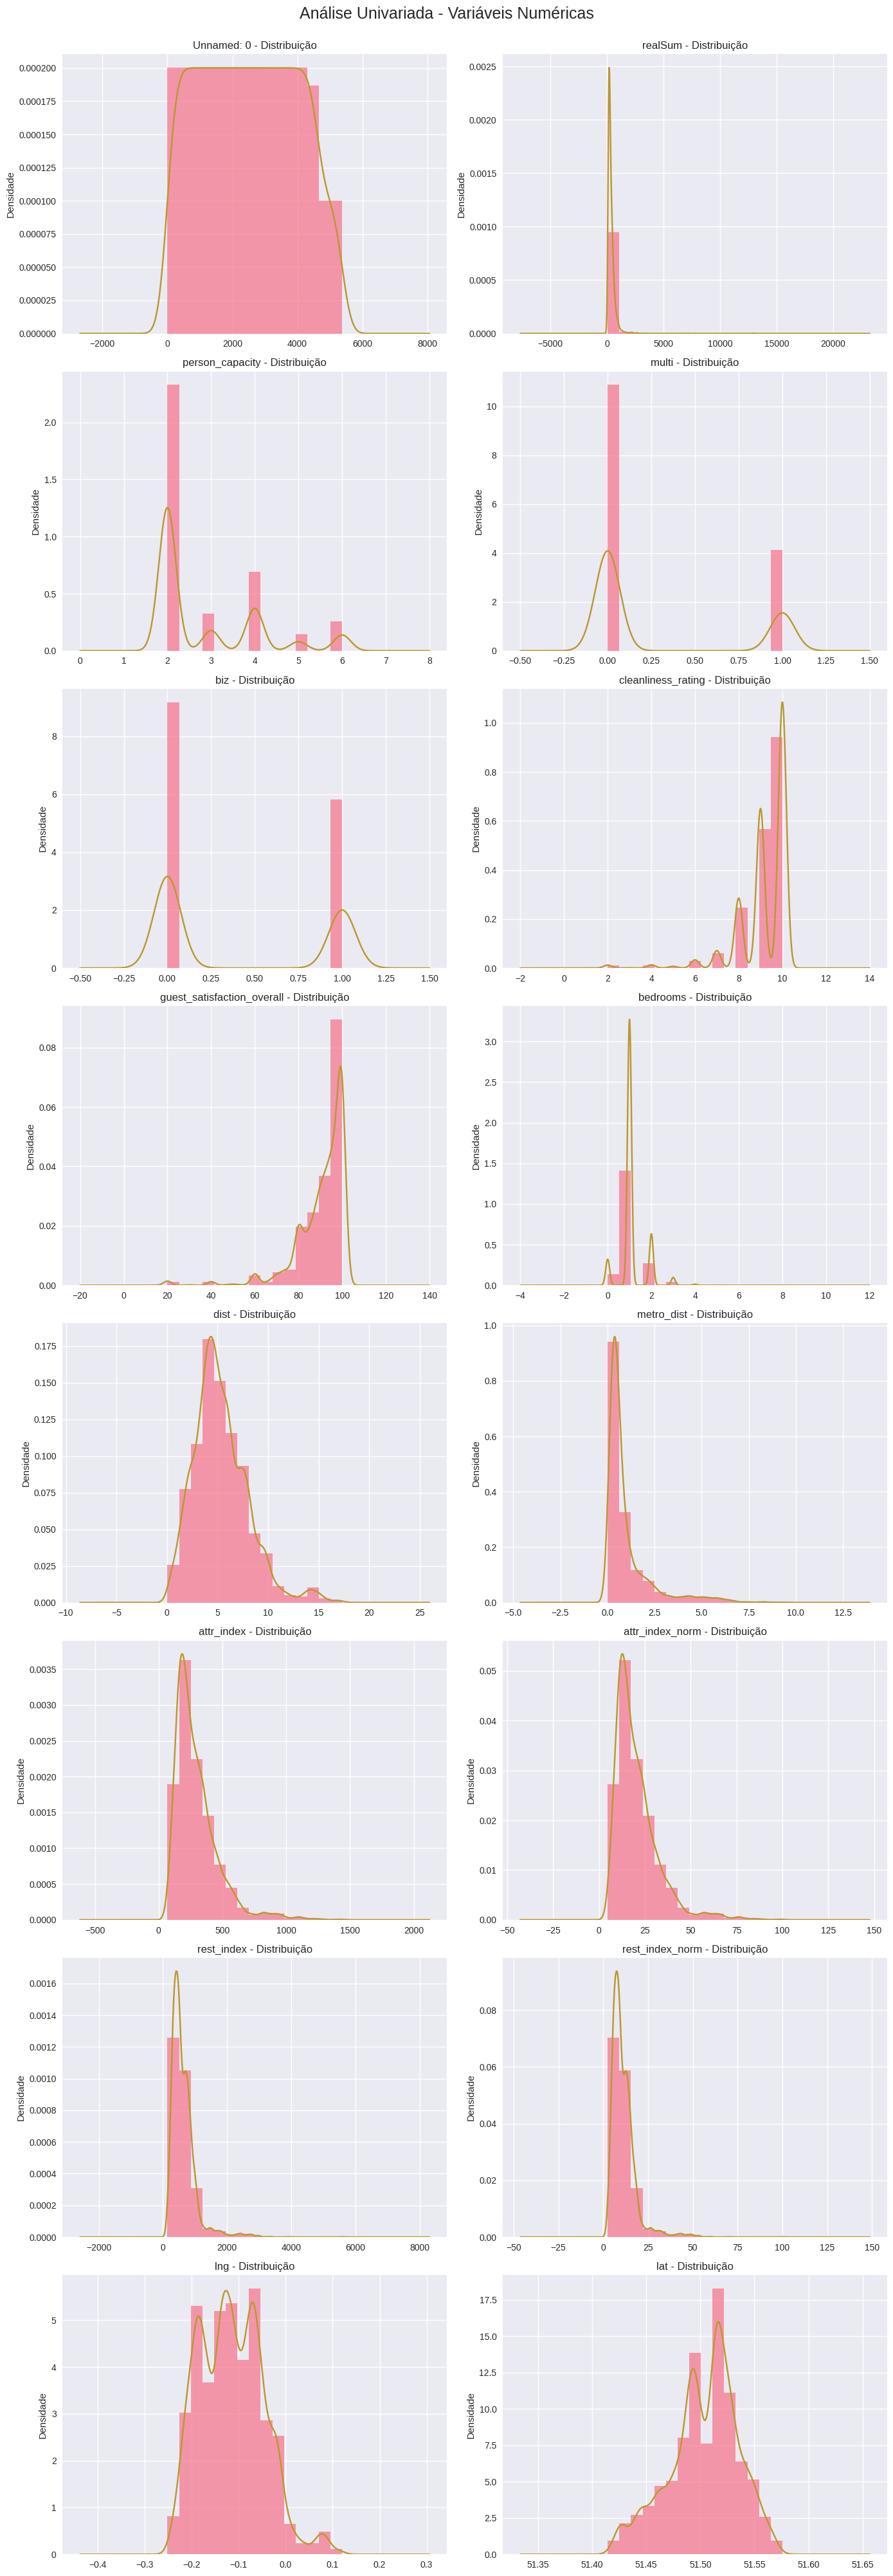

In [ ]:
# Total das variáveis numéricas
vars_to_plot = numeric_vars[:16]   
cols = 2
rows = 8

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
fig.suptitle('Análise Univariada - Variáveis Numéricas', fontsize=18, y=1.0)

axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]

    
    # Histograma
    ax.hist(df[var].dropna(), bins=15, alpha=0.7, density=True)

    # Linha de densidade (KDE)
    df[var].dropna().plot.density(ax=ax)

    ax.set_title(f'{var} - Distribuição')
    ax.set_ylabel('Densidade')

plt.tight_layout()
plt.show()


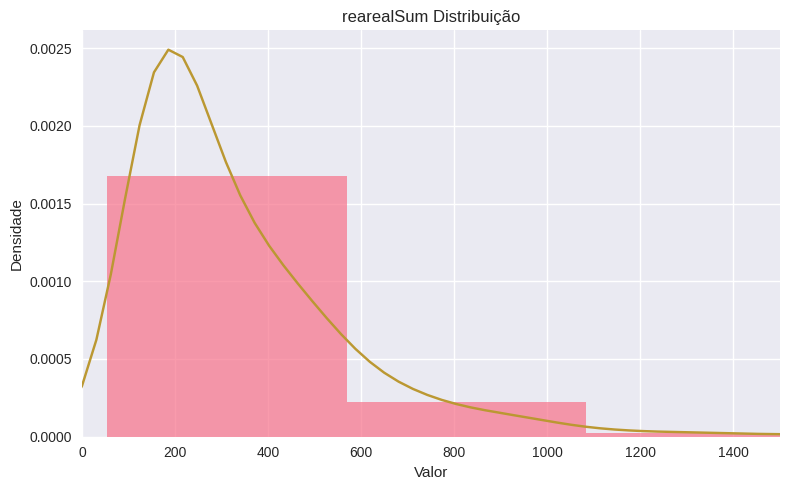

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["realSum"].dropna(), bins=30, alpha=0.7, density=True)
df["realSum"].dropna().plot.density()

plt.title("rearealSum Distribuição")
plt.xlabel("Valor")
plt.ylabel("Densidade")

plt.xlim(0, 1500)   

plt.tight_layout()
plt.show()


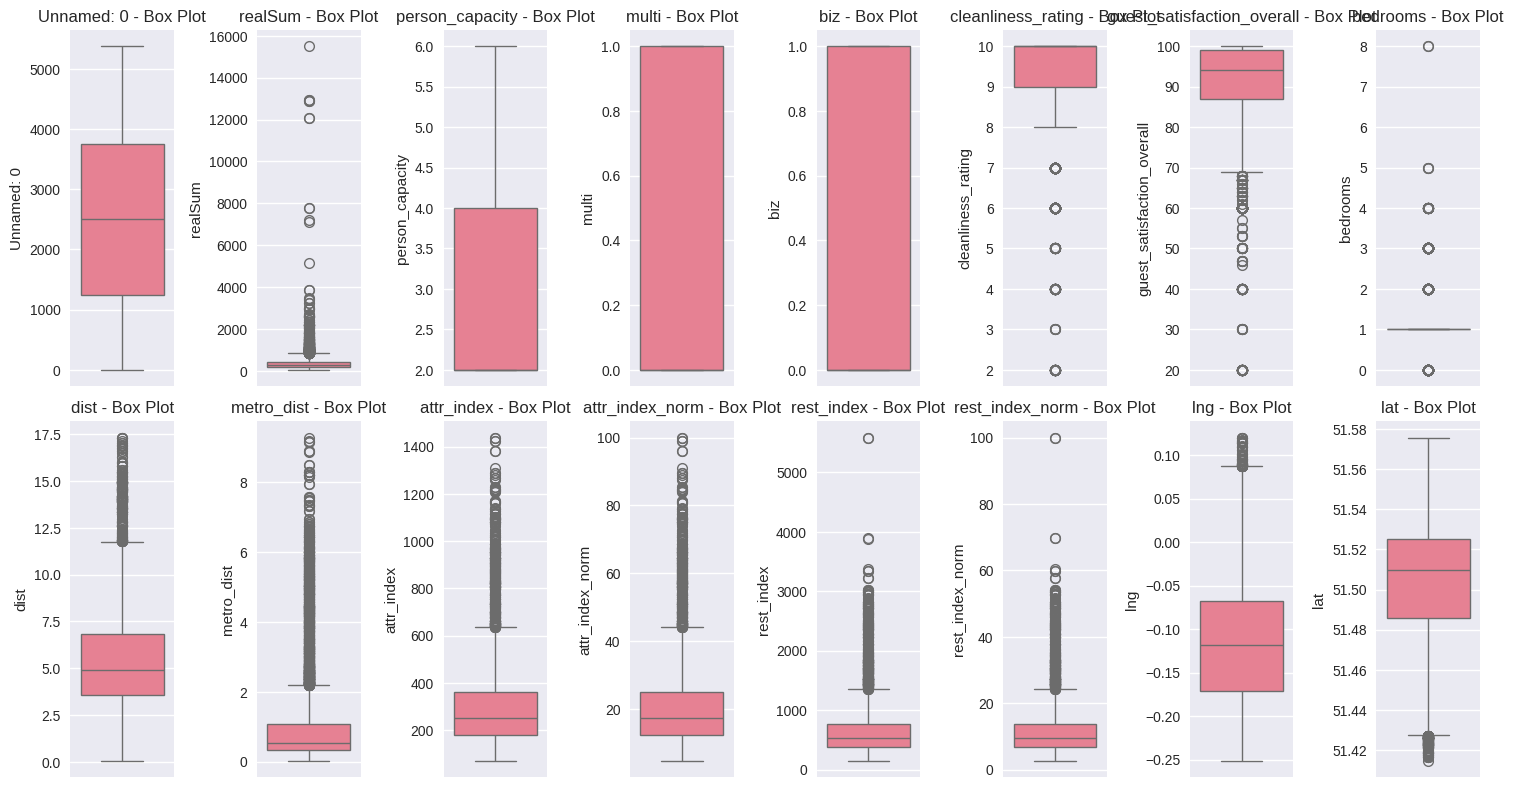

In [ ]:
# Box plots para identificar outliers
plt.figure(figsize=(15, 8))
numeric_data = df[numeric_vars].select_dtypes(include=[np.number])

variables_to_plot = numeric_data.columns[:16]
for i, var in enumerate(variables_to_plot):
    plt.subplot(2, 8, i+1)
    sns.boxplot(y=df[var])
    plt.title(f'{var} - Box Plot')
plt.tight_layout()
plt.show()

In [ ]:
# 2. ANÁLISE DE VARIÁVEIS CATEGÓRICAS
print("\n2️⃣ ANÁLISE DE VARIÁVEIS CATEGÓRICAS:")


2️⃣ ANÁLISE DE VARIÁVEIS CATEGÓRICAS:


In [ ]:
# Análise de frequências
for var in categorical_vars:
    if var in df.columns:
        print(f"\n📊 {var.upper()}:")
        freq_table = df[var].value_counts()
        freq_percent = df[var].value_counts(normalize=True) * 100

        freq_df = pd.DataFrame({
            'Frequência': freq_table,
            'Percentual': freq_percent
        })
        print(freq_df.head(10))

        # Medida de concentração (Índice de Herfindahl)
        herfindahl = (freq_percent/100).pow(2).sum()
        print(f"  Índice de Herfindahl: {herfindahl:.3f}")
        print(f"  Entropia: {stats.entropy(freq_table):.3f}")


📊 ROOM_TYPE:
                 Frequência  Percentual
room_type                              
Private room           5559   55.628940
Entire home/apt        4384   43.870709
Shared room              50    0.500350
  Índice de Herfindahl: 0.502
  Entropia: 0.714

📊 ROOM_SHARED:
             Frequência  Percentual
room_shared                        
False              9943    99.49965
True                 50     0.50035
  Índice de Herfindahl: 0.990
  Entropia: 0.031

📊 ROOM_PRIVATE:
              Frequência  Percentual
room_private                        
True                5559    55.62894
False               4434    44.37106
  Índice de Herfindahl: 0.506
  Entropia: 0.687

📊 HOST_IS_SUPERHOST:
                   Frequência  Percentual
host_is_superhost                        
False                    8420   84.258981
True                     1573   15.741019
  Índice de Herfindahl: 0.735
  Entropia: 0.435


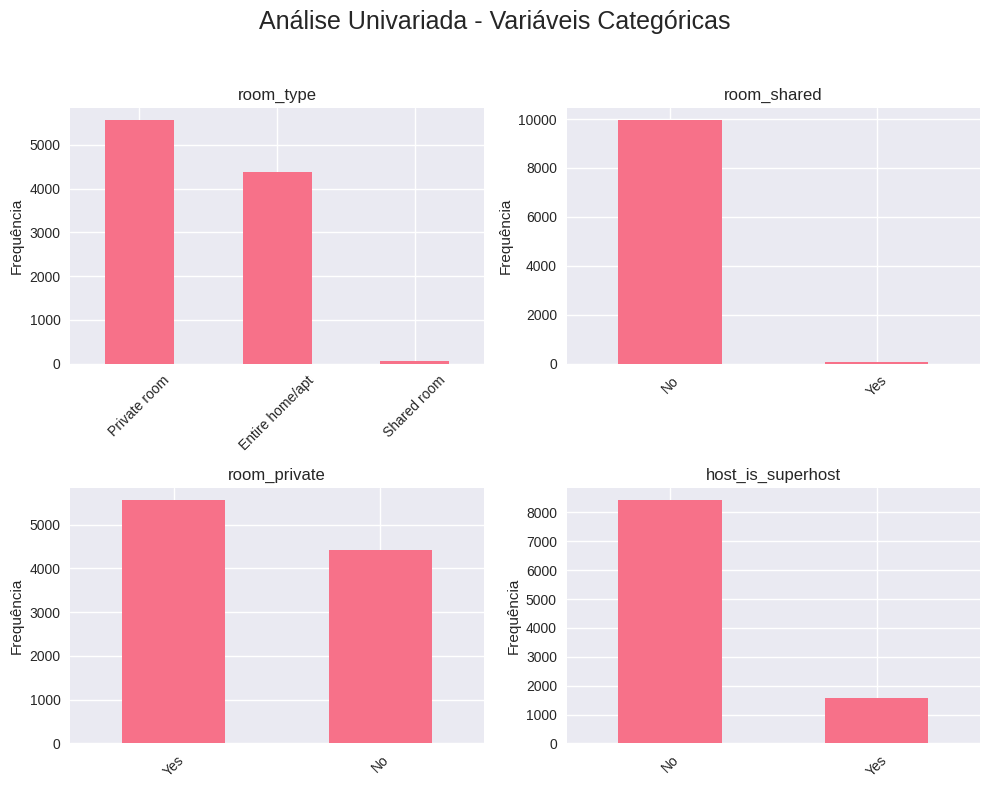

In [ ]:

cols = 2
rows = math.ceil(len(categorical_vars)/2)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
axes = axes.flatten()  # facilita indexação mesmo quando rows*cols == 1

fig.suptitle('Análise Univariada - Variáveis Categóricas', fontsize=18)

for idx, var in enumerate(categorical_vars):
        ax = axes[idx]

        if df[var].dtype == 'bool':
                counts = df[var].map({True:'Yes', False:'No'}).value_counts()
        else:
                counts = df[var].value_counts().head(10)  

        counts.plot(kind='bar', ax=ax)
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel('')
        ax.set_ylabel('Frequência')
        ax.set_title(f'{var}')
        # ajusta o layout deixando espaço para o suptitle

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


ANÁLISE EXPLORATÓRIA BIVARIADA

In [ ]:
# 1. CORRELAÇÃO ENTRE VARIÁVEIS NUMÉRICAS
print("\n1️⃣ MATRIZ DE CORRELAÇÃO:")


1️⃣ MATRIZ DE CORRELAÇÃO:


In [ ]:
# Calcular matriz de correlação
correlation_matrix = df[numeric_vars].corr()

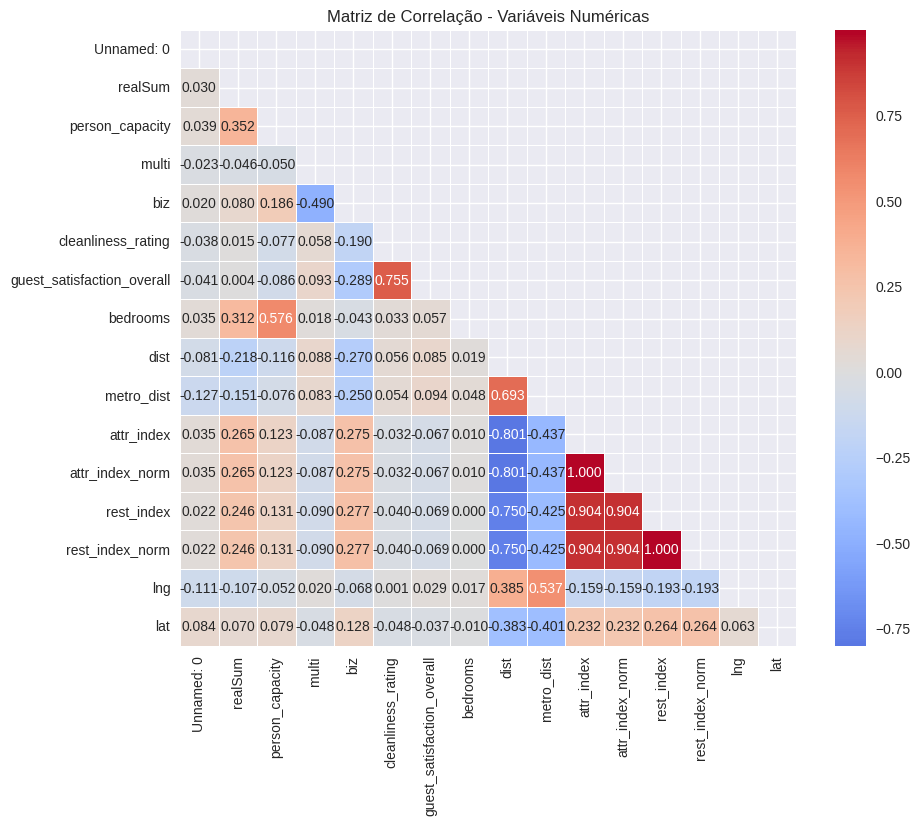

In [ ]:
# Visualizar heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            mask=mask, 
            annot=True, 
            cmap='coolwarm',
            center=0, 
            square=True, 
            linewidths=0.5,
            fmt=".3f",)
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.show()

In [ ]:
# Identificar correlações fortes
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:  # Correlação forte
            strong_corr.append({
                'var1': correlation_matrix.columns[i],
                'var2': correlation_matrix.columns[j],
                'correlation': corr_val
            })

In [ ]:
if strong_corr:
    print("\n🔥 CORRELAÇÕES FORTES (|r| > 0.5):")
    for corr in strong_corr:
        print(f"  {corr['var1']} ↔ {corr['var2']}: {corr['correlation']:.3f}")


🔥 CORRELAÇÕES FORTES (|r| > 0.5):
  person_capacity ↔ bedrooms: 0.576
  cleanliness_rating ↔ guest_satisfaction_overall: 0.755
  dist ↔ metro_dist: 0.693
  dist ↔ attr_index: -0.801
  dist ↔ attr_index_norm: -0.801
  dist ↔ rest_index: -0.750
  dist ↔ rest_index_norm: -0.750
  metro_dist ↔ lng: 0.537
  attr_index ↔ attr_index_norm: 1.000
  attr_index ↔ rest_index: 0.904
  attr_index ↔ rest_index_norm: 0.904
  attr_index_norm ↔ rest_index: 0.904
  attr_index_norm ↔ rest_index_norm: 0.904
  rest_index ↔ rest_index_norm: 1.000


In [ ]:
# 2. ANÁLISE TARGET vs VARIÁVEIS NUMÉRICAS
print("\n2️⃣ TARGET vs VARIÁVEIS NUMÉRICAS:")


2️⃣ TARGET vs VARIÁVEIS NUMÉRICAS:


In [ ]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()

corr = correlation_matrix['realSum'].abs().sort_values(ascending=False)

top3 = corr.index[1:4].tolist()  # Ignora o próprio realSum
print("Top 3 variáveis mais correlacionadas ao realSum:", top3)


Top 3 variáveis mais correlacionadas ao realSum: ['person_capacity', 'bedrooms', 'attr_index']


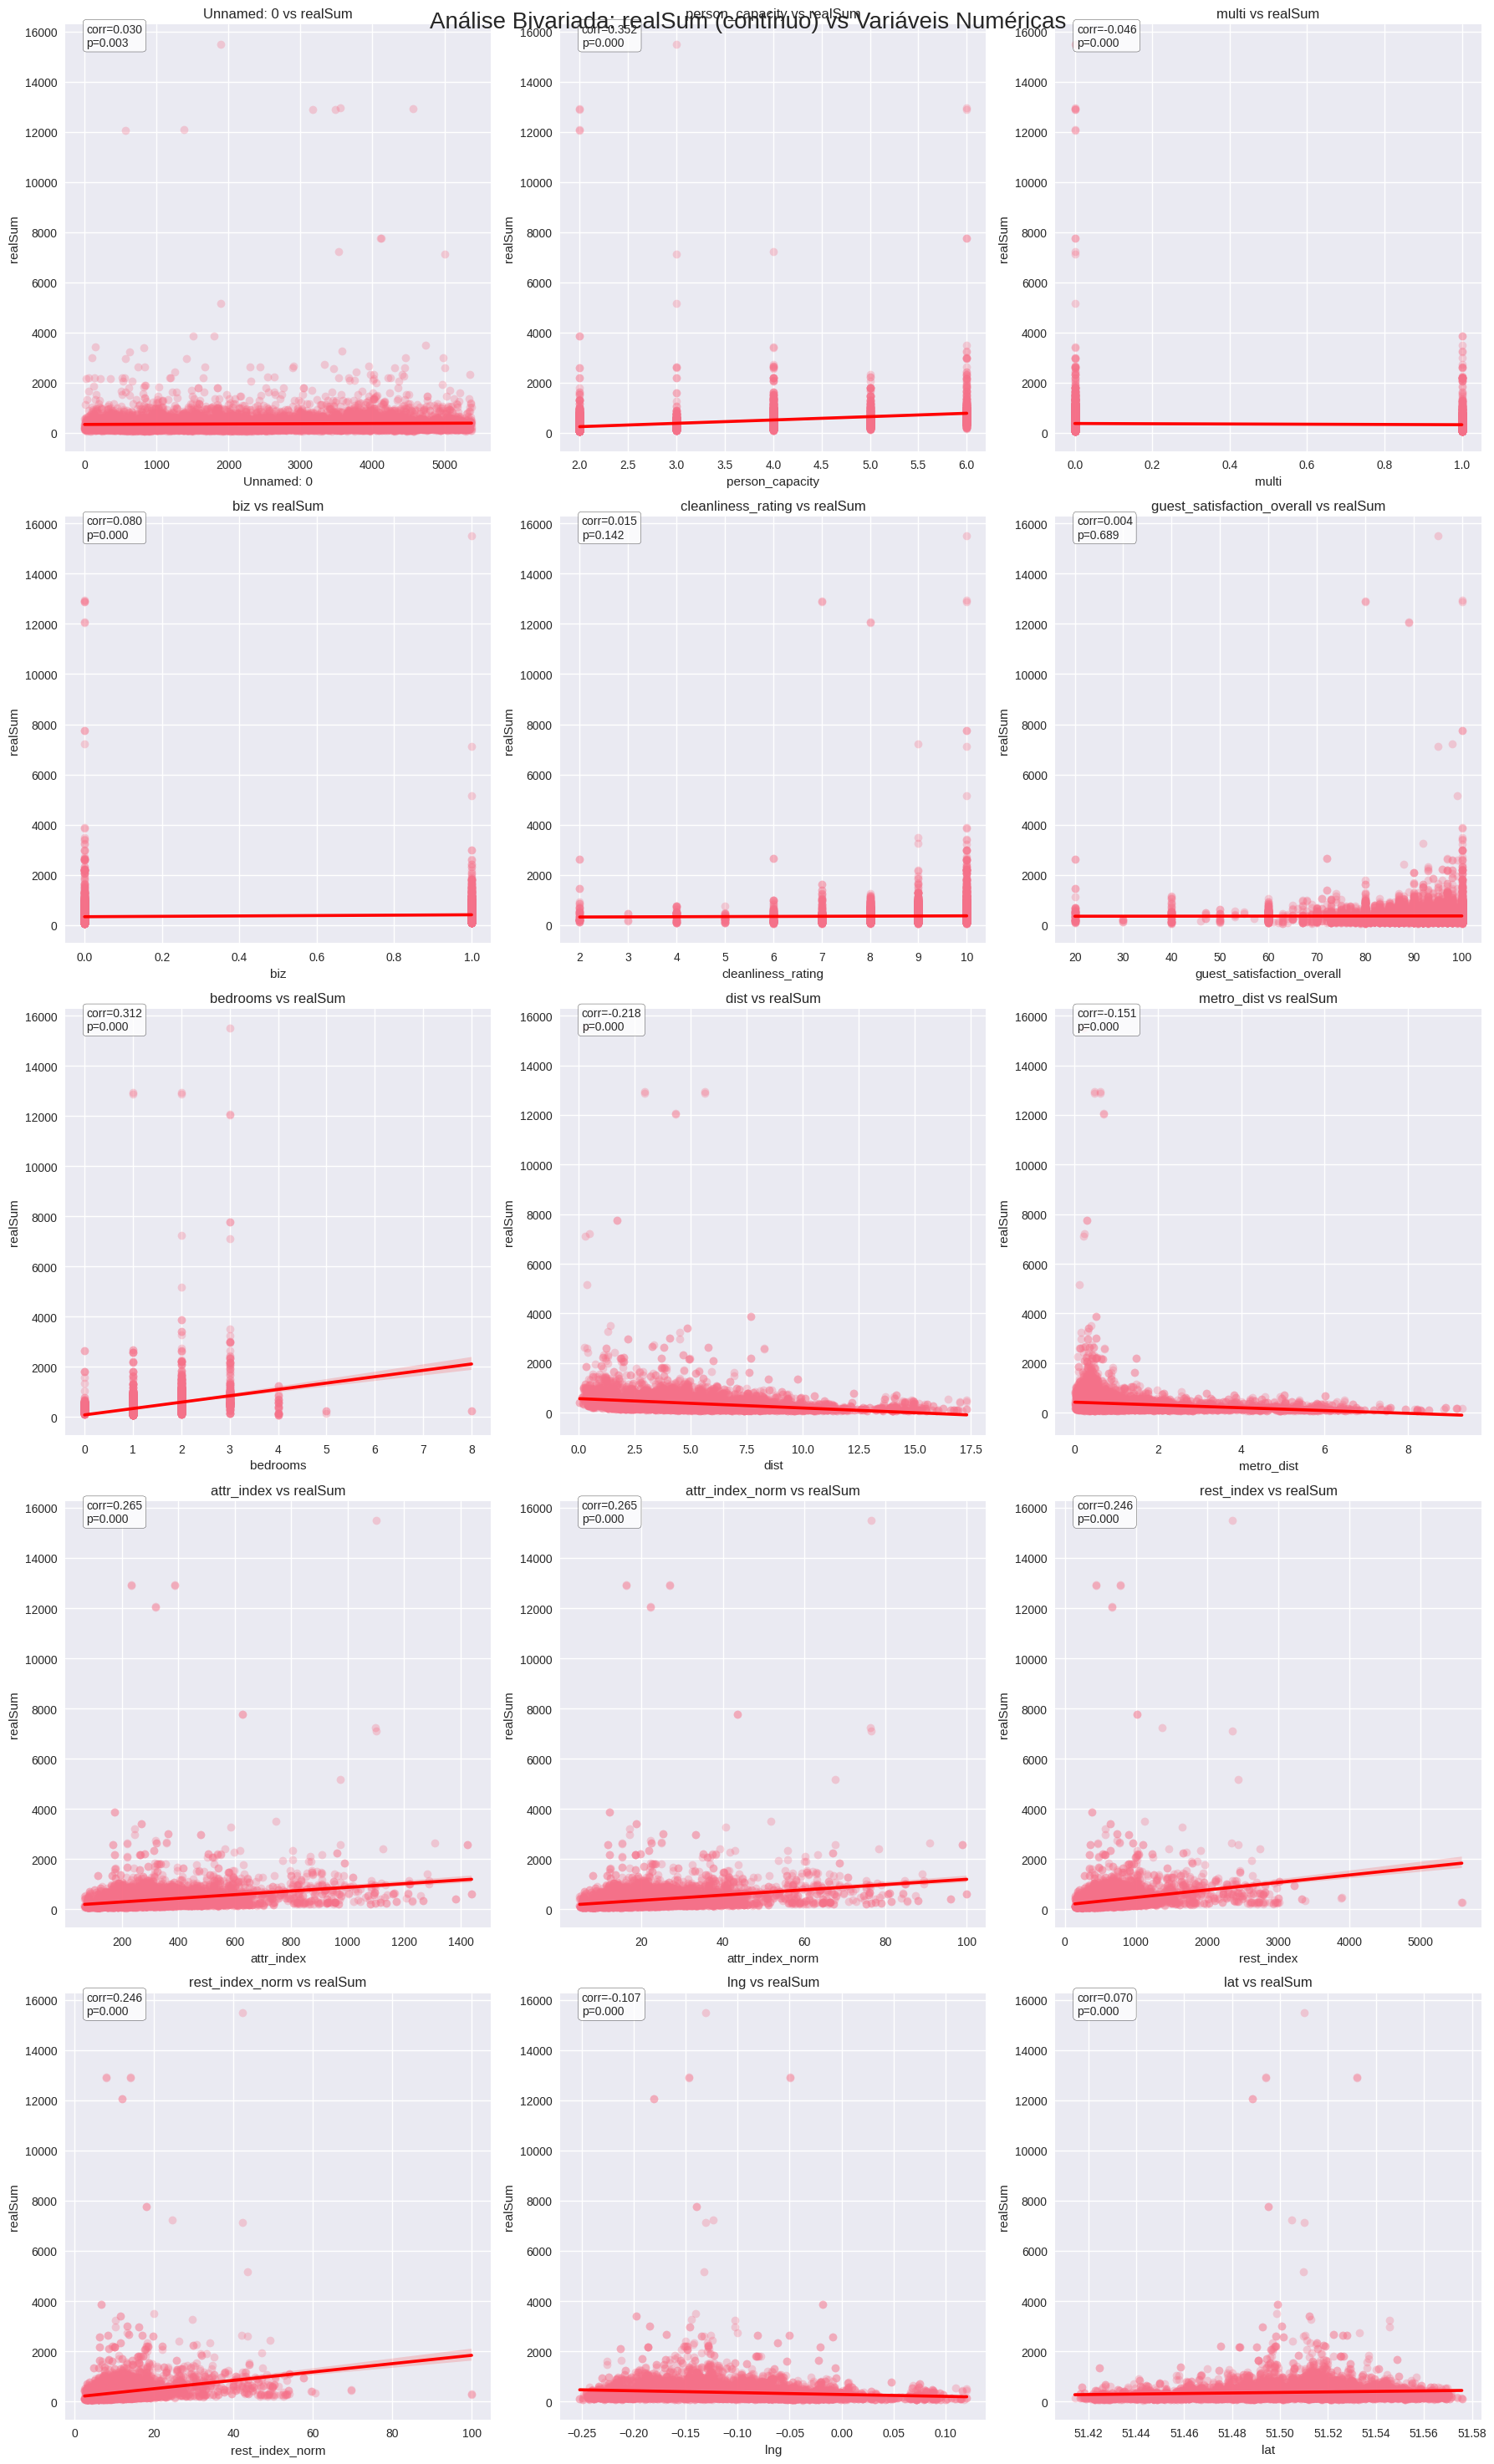

In [ ]:

# Variáveis numéricas selecionadas para análise
target_var = 'realSum'
numeric_for_analysis = [var for var in numeric_vars if var != target_var]


n = len(numeric_for_analysis)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
axes = axes.flatten()

fig.suptitle(f'Análise Bivariada: {target_var} (contínuo) vs Variáveis Numéricas', fontsize=20)

for i, var in enumerate(numeric_for_analysis):

    if var not in df.columns:
        continue

    ax = axes[i]

    # Scatter plot + regressão linear
    sns.regplot(
        data=df,
        x=var,
        y=target_var,
        scatter_kws={'alpha': 0.3},
        line_kws={'color': 'red'},
        ax=ax
    )
    
    ax.set_title(f'{var} vs {target_var}')

    # Correlação Pearson
    x = df[var].dropna()
    y = df[target_var].dropna()

    corr, pval = pearsonr(x, y)

    # Texto do p-value e correlação
    ax.text(
        0.05, 0.95,
        f'corr={corr:.3f}\np={pval:.3f}',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

plt.tight_layout()
plt.show()


In [ ]:
# 3. ANÁLISE TARGET vs VARIÁVEIS CATEGÓRICAS
print("\n3️⃣ TARGET vs VARIÁVEIS CATEGÓRICAS:")


3️⃣ TARGET vs VARIÁVEIS CATEGÓRICAS:


In [ ]:
df["realSum_log"] = np.log1p(df["realSum"])


In [ ]:
categorical_for_analysis = [
    "room_type",
    "room_shared",
    "room_private",
    "host_is_superhost",
]

for var in categorical_for_analysis:
    print(f"\n===== {var.upper()} =====")
    summary = df.groupby(var)["realSum"].agg(["count", "mean", "median", "std"]).round(2)
    print(summary)



===== ROOM_TYPE =====
                 count    mean  median     std
room_type                                     
Entire home/apt   4384  544.70  450.15  525.96
Private room      5559  220.40  180.39  366.76
Shared room         50  179.82  155.11   97.44

===== ROOM_SHARED =====
             count    mean  median     std
room_shared                               
False         9943  363.39  262.71  472.31
True            50  179.82  155.11   97.44

===== ROOM_PRIVATE =====
              count    mean  median     std
room_private                               
False          4434  540.58  446.15  524.50
True           5559  220.40  180.39  366.76

===== HOST_IS_SUPERHOST =====
                   count    mean  median     std
host_is_superhost                               
False               8420  365.38  269.06  455.83
True                1573  346.90  237.31  546.94


Variáveis válidas: ['room_type', 'room_shared', 'room_private', 'host_is_superhost', 'multi', 'biz']


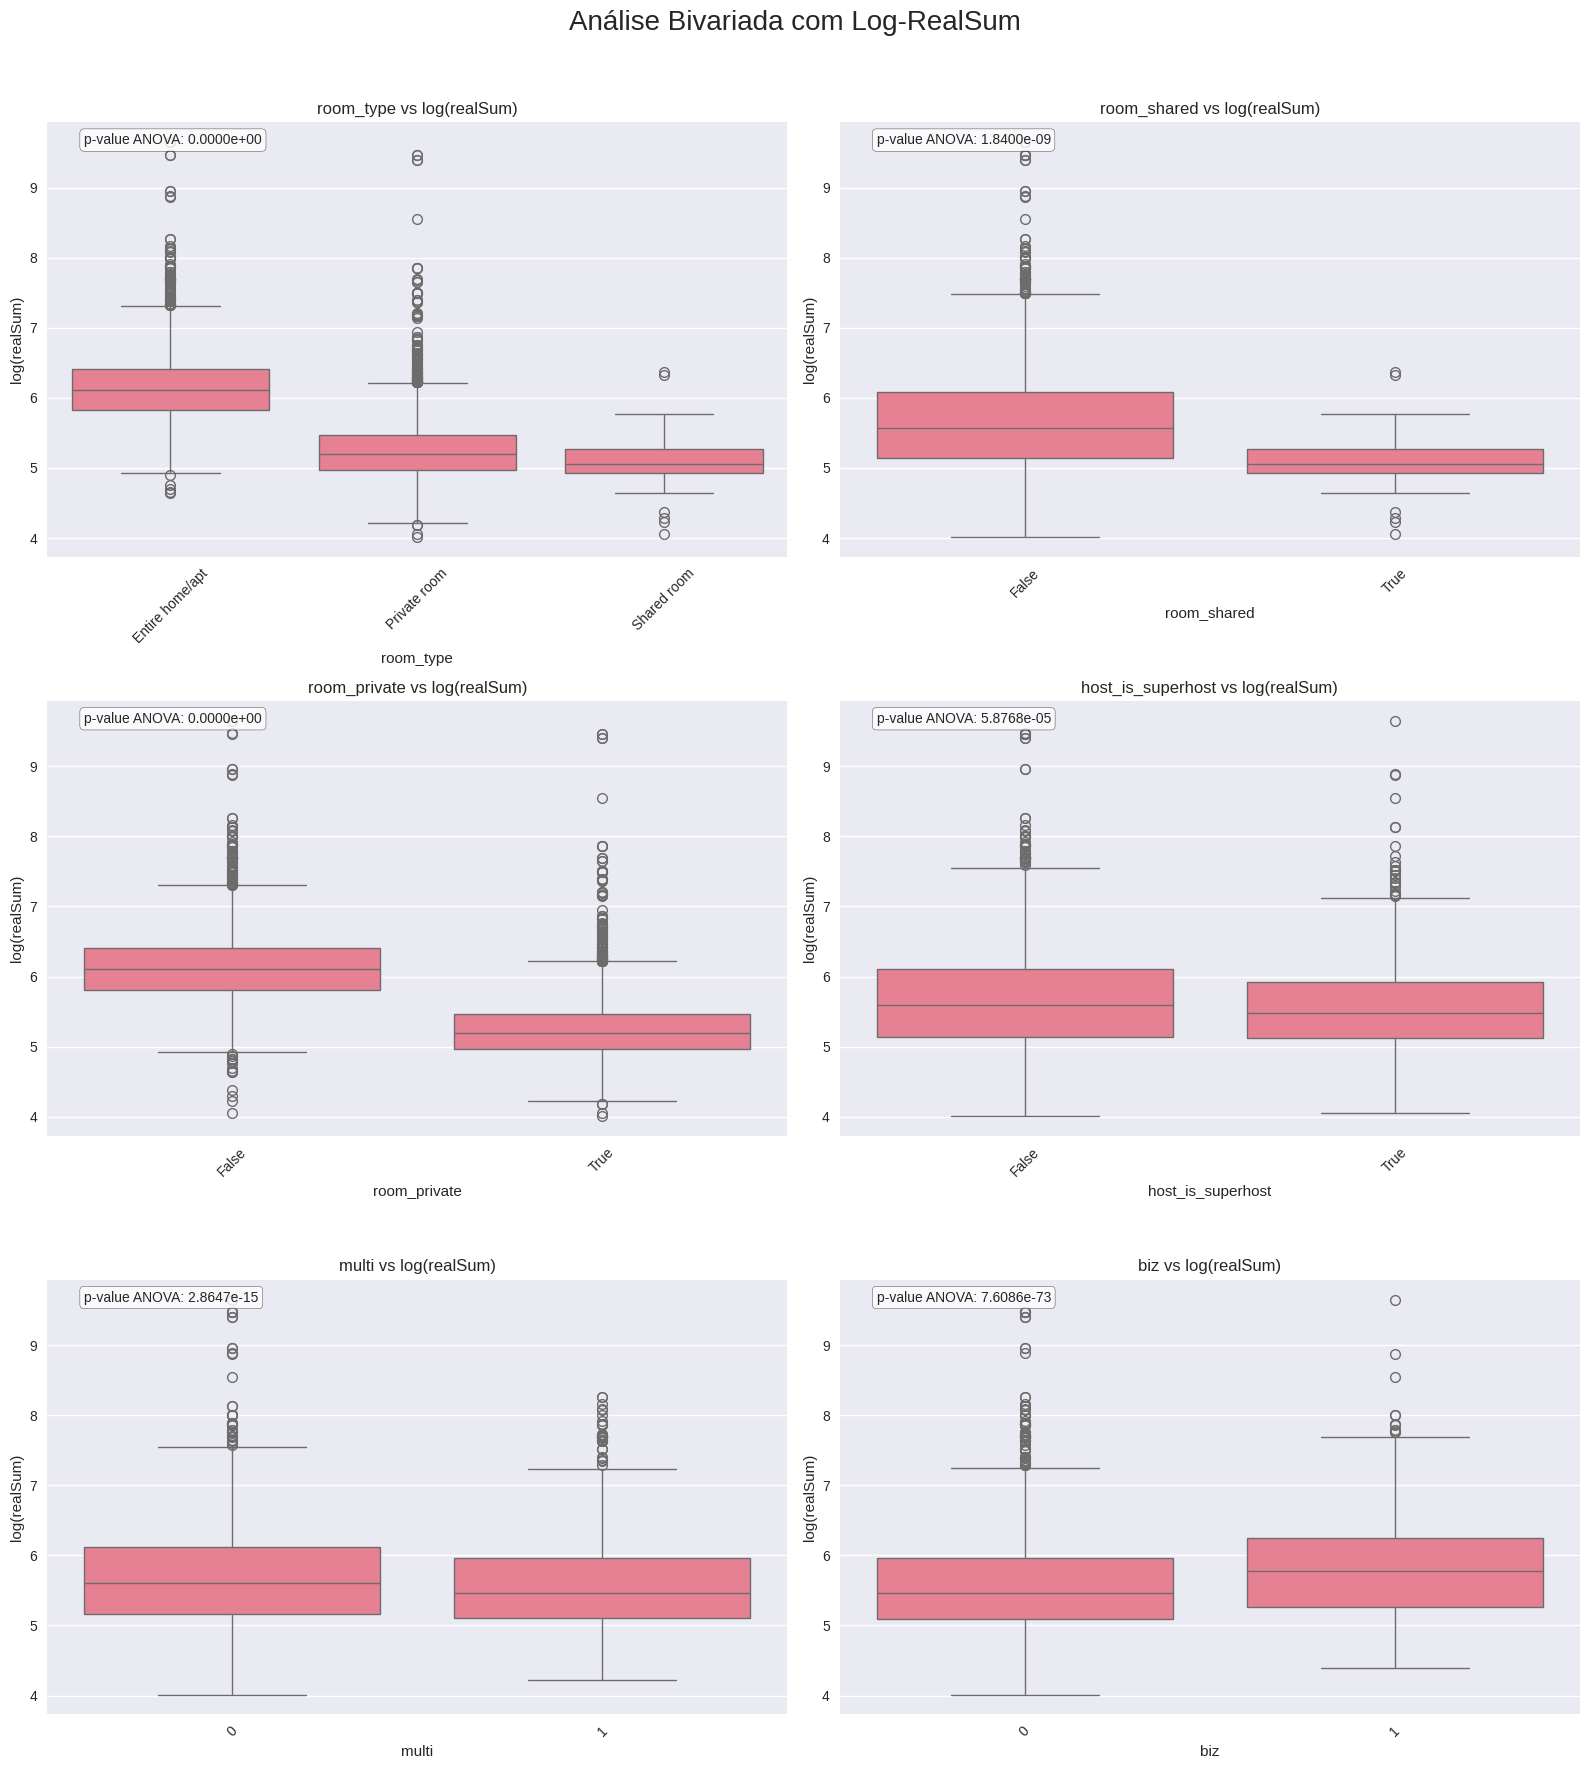

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats
import numpy as np


# ✅ Garantir valores válidos para log
df = df[df["realSum"] > 0].copy()
df["realSum_log"] = np.log1p(df["realSum"])

categorical_for_analysis = [
    "room_type",
    "room_shared",
    "room_private",
    "host_is_superhost",
    "multi",
    "biz",
    "cidade",
    "tipo_dia"
]

# ✅ Filtrar apenas variáveis categóricas válidas
valid_categoricals = [
    var for var in categorical_for_analysis
    if var in df.columns and df[var].nunique() > 1
]

print("Variáveis válidas:", valid_categoricals)

# ✅ PROTEÇÃO CONTRA LISTA VAZIA
if len(valid_categoricals) == 0:
    raise ValueError("Nenhuma variável categórica válida para plotar.")

cols = 2
rows = math.ceil(len(valid_categoricals) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows))
axes = axes.flatten()

fig.suptitle("Análise Bivariada com Log-RealSum", fontsize=20)

for i, var in enumerate(valid_categoricals):
    ax = axes[i]

    sns.boxplot(data=df, x=var, y="realSum_log", ax=ax)

    ax.set_title(f'{var} vs log(realSum)')
    ax.set_ylabel("log(realSum)")
    ax.tick_params(axis='x', rotation=45)

    # ✅ ANOVA segura
    groups = [df[df[var] == c]["realSum_log"].dropna() for c in df[var].dropna().unique()]

    if len(groups) >= 2:
        f_stat, p_value = stats.f_oneway(*groups)
        ax.text(
            0.05, 0.95,
            f'p-value ANOVA: {p_value:.4e}',
            transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

# ✅ Remover eixos vazios
for j in range(len(valid_categoricals), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Análise Espacial RealSum

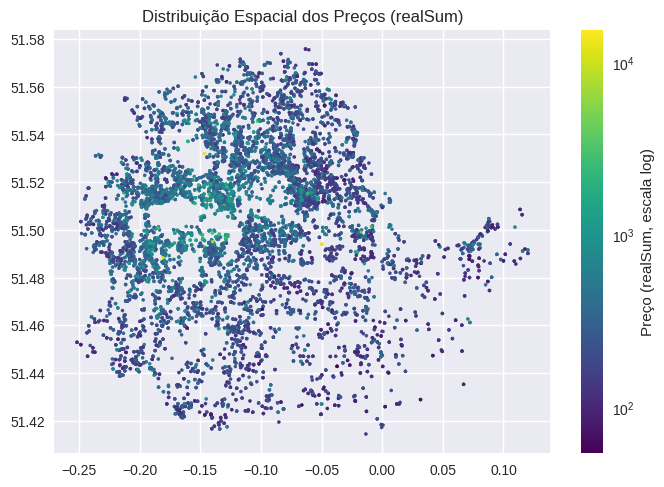

In [15]:
from matplotlib.colors import LogNorm

plt.scatter(
    df["lng"], df["lat"],
    c=df["realSum"],
    cmap="viridis",
    s=5,
    norm=LogNorm()
)
plt.colorbar(label="Preço (realSum, escala log)")
plt.title("Distribuição Espacial dos Preços (realSum)")
plt.show()


Análise Multivalorada

In [ ]:
# 2. Análise de grupos interessantes
print("\n2️⃣ ANÁLISE DE GRUPOS:")


2️⃣ ANÁLISE DE GRUPOS:


In [ ]:
# Faixa de preço (4 quantis)
df['Price_Group'] = pd.qcut(df['realSum'], q=4,
                            labels=['Baixo', 'Médio-Baixo', 'Médio-Alto', 'Alto'])

# Faixa de distância do centro
df['Dist_Group'] = pd.cut(
    df['dist'],
    bins=[0, 1, 3, 10, df['dist'].max()],
    labels=['Muito perto', 'Perto', 'Longe', 'Muito Longe'],
    include_lowest=True
)

# Faixa de satisfação
df['Satisfaction_Group'] = pd.cut(
    df['guest_satisfaction_overall'],
    bins=[0, 60, 80, 95, 100],
    labels=['Baixa', 'Média', 'Alta', 'Excelente']
)

# Capacidade categorizada
df['Capacity_Group'] = df['person_capacity'].map({
    2: 'Pequeno',
    4: 'Médio',
    6: 'Grande'
})


In [ ]:
analysis = df.groupby(['room_type', 'host_is_superhost'])['guest_satisfaction_overall'] \
             .agg(['mean', 'count']) \
             .round(2)

print("\n📊 SATISFAÇÃO MÉDIA POR TIPO DE QUARTO E SUPERHOST:")
print(analysis)



📊 SATISFAÇÃO MÉDIA POR TIPO DE QUARTO E SUPERHOST:
                                    mean  count
room_type       host_is_superhost              
Entire home/apt False              88.55   3880
                True               95.71    504
Private room    False              90.36   4496
                True               97.20   1063
Shared room     False              87.48     44
                True               97.67      6


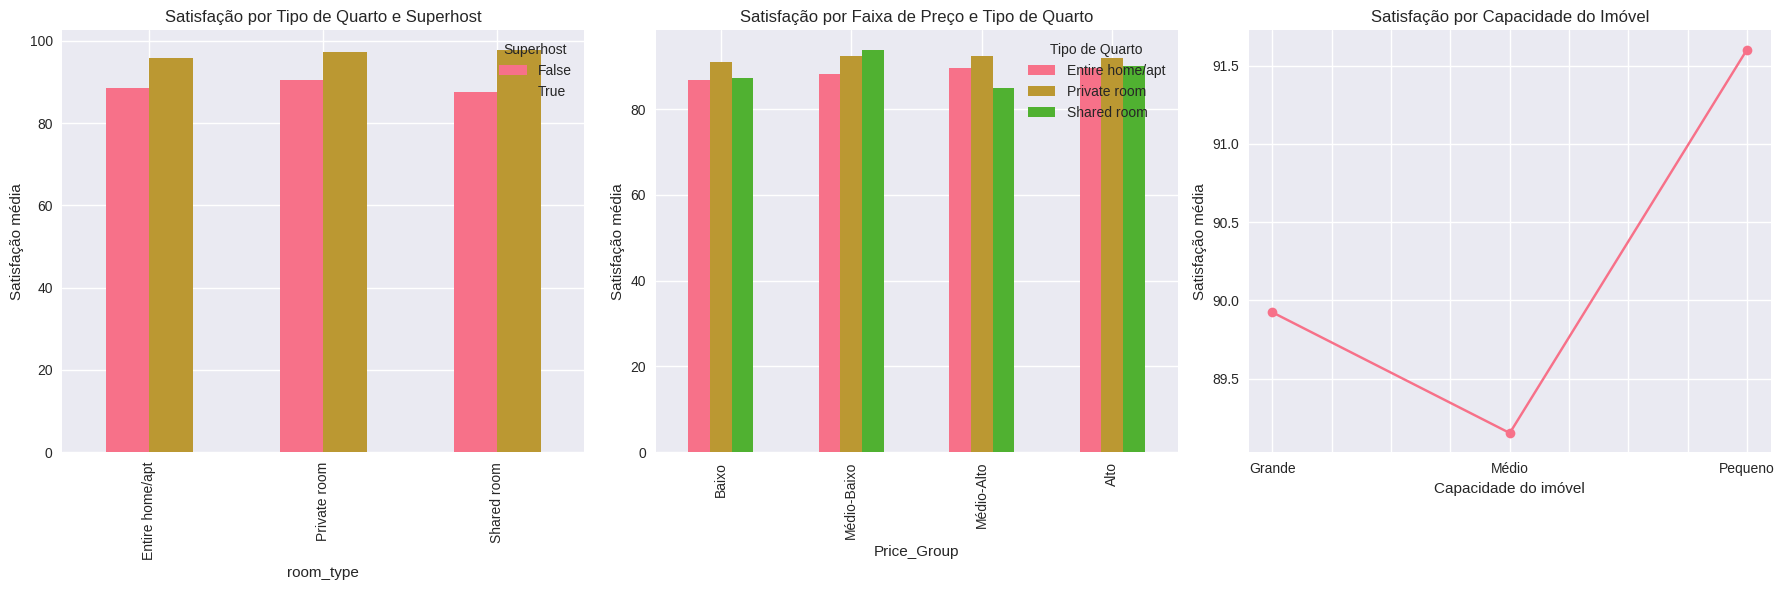

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1 — Por tipo de quarto
s_room = df.groupby(['room_type', 'host_is_superhost'])['guest_satisfaction_overall'] \
           .mean().unstack()

s_room.plot(kind='bar', ax=axes[0])
axes[0].set_title('Satisfação por Tipo de Quarto e Superhost')
axes[0].set_ylabel('Satisfação média')
axes[0].legend(title='Superhost')

# 2 — Por faixa de preço
s_price = df.groupby(['Price_Group', 'room_type'])['guest_satisfaction_overall'] \
            .mean().unstack()

s_price.plot(kind='bar', ax=axes[1])
axes[1].set_title('Satisfação por Faixa de Preço e Tipo de Quarto')
axes[1].set_ylabel('Satisfação média')
axes[1].legend(title='Tipo de Quarto')

# 3 — Por capacidade
s_capacity = df.groupby('Capacity_Group')['guest_satisfaction_overall'].mean()

s_capacity.plot(kind='line', marker='o', ax=axes[2])
axes[2].set_title('Satisfação por Capacidade do Imóvel')
axes[2].set_ylabel('Satisfação média')
axes[2].set_xlabel('Capacidade do imóvel')

plt.tight_layout()
plt.show()
